# Exploratory Data Analysis (EDA) – California Housing Dataset

Den här Notebook syfte är att genomföra en omfattande så kallad EDA (Explorativ Data Analysis) av California Housing-datasetet, som innehåller aggregerad husstatistik per distrikt i California stat. Jag väljer att komentera kod på engelska enligt Python Community konvention.


In [115]:
# list files in current directory to show what is included in the repository
import os
print(os.listdir())

['California_Housing_EDA.ipynb', 'california_map.png', 'housing.csv', 'Kursuppgiften frågor Jorge B.docx']


In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading the data
df = pd.read_csv('housing.csv')



## Dataset Overview

In [117]:

print("Shape (rows, columns):", df.shape, "\n")
# Display the first few rows of the DataFrame
df.head()



Shape (rows, columns): (20640, 10) 



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# Dataset kolumner Förklaring

Each row (observation) represents a California census block group (a district-like geographic area), i.e. not an individual house.

| Kolumn | Beskrivning |
|----------|-------------|
| `longitude` |	Longitud (längdgrad) för området. Mer negativa värden innebär längre västerut.|
| `latitude` |	Latitud (breddgrad) för området. Högre värden innebär längre norrut.|
 `housing_median_age` |	Medianåldern på bostäderna i området (år).|
| `total_rooms` |	Totalt antal rum i alla bostäder inom området.|
| `total_bedrooms` |	Totalt antal sovrum i alla bostäder inom området.|
| `population` |	Totalt antal invånare i området.|
| `households` |	Antal hushåll i området. Ett hushåll motsvarar en bostad som bebos av en eller flera personer.|
| `median_income`  |	Medianinkomst för hushållen i området. Värdet är inte i dollar utan i tiotusentals dollar. Exempel: 3,5 = 35000 USD.|
| `median_house_value` |Medianvärdet på bostäderna i området (USD). Detta är ofta målvariabeln som man vill prediktera.|
| `ocean_proximity` | 	Kategorisk variabel som beskriver närhet till havet.|
## Ocean Proximity Kategorier

- `NEAR BAY` – Nära San Francisco Bay
- `NEAR OCEAN` – Nära Stilla havet
- `<1H OCEAN` – Mindre än en timmes resa från havet
- `INLAND` – Inåt landet, ej nära kusten
- `ISLAND` – På en ö

Dessa kategorier bör konverteras till numeriska värde, jag har läst att det kan vara 5 kolumner med flaggor "0 or 1"



In [118]:
print("\nInfo on DataFrame:")
#
df.info()



Info on DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [119]:

print("\n")
print("\nMissing values:")
# Display the count of missing values for each column
display(df.isnull().sum())







Missing values:


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [120]:
print("\n")
print("\nColumns with missing values:")
# List only columns that have missing values
print(df.columns[df.isnull().any()].tolist())

print("\nCount of non-null values:")
# Display the count of non-null values for each column
display(df.count())






Columns with missing values:
['total_bedrooms']

Count of non-null values:


longitude             20640
latitude              20640
housing_median_age    20640
total_rooms           20640
total_bedrooms        20433
population            20640
households            20640
median_income         20640
median_house_value    20640
ocean_proximity       20640
dtype: int64

In [121]:
print("\nSummary statistics:")
# Display summary statistics for all columns, including categorical ones like ocean_proximity
display(df.describe(include='all'))


Summary statistics:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1H OCEAN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9136
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,NaN
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,NaN
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,NaN
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,NaN
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,NaN
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,NaN


Det verkar finnas en top på 500000 median_house_value där dyrare hem får max värde. Förmodligen en miss/beslut tagen under data insamling (enkät) Detta bör hanteras

## Numeriska kolumner / Feature Distributions

In [122]:
# Identify numeric columns for further analysis
num_cols = df.select_dtypes(include=np.number).columns



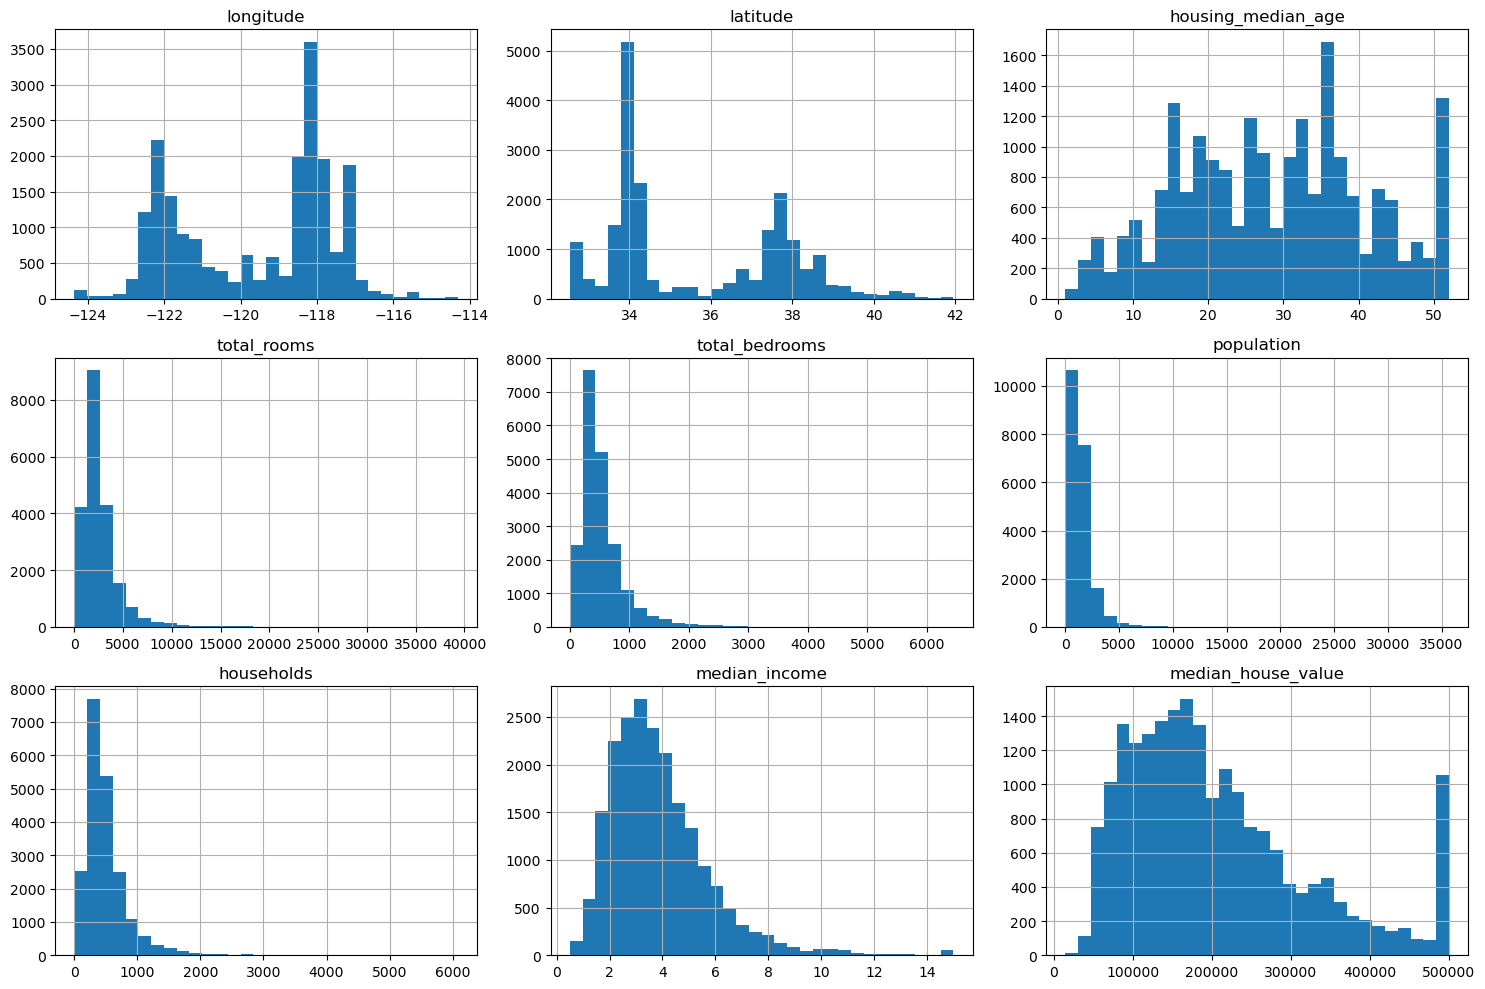

In [123]:
# Create histograms for all numerical columns
df[num_cols].hist(figsize=(15,10), bins=30)
# Adjust layout and show the plots
plt.tight_layout()
plt.show()

## Kommentar
Det verkar finnas en top på 500000 median_house_value där dyrare hem får max värde. Förmodligen en miss/beslut tagen under data insamling (enkät) Detta bör hanteras

## Correlation Analys

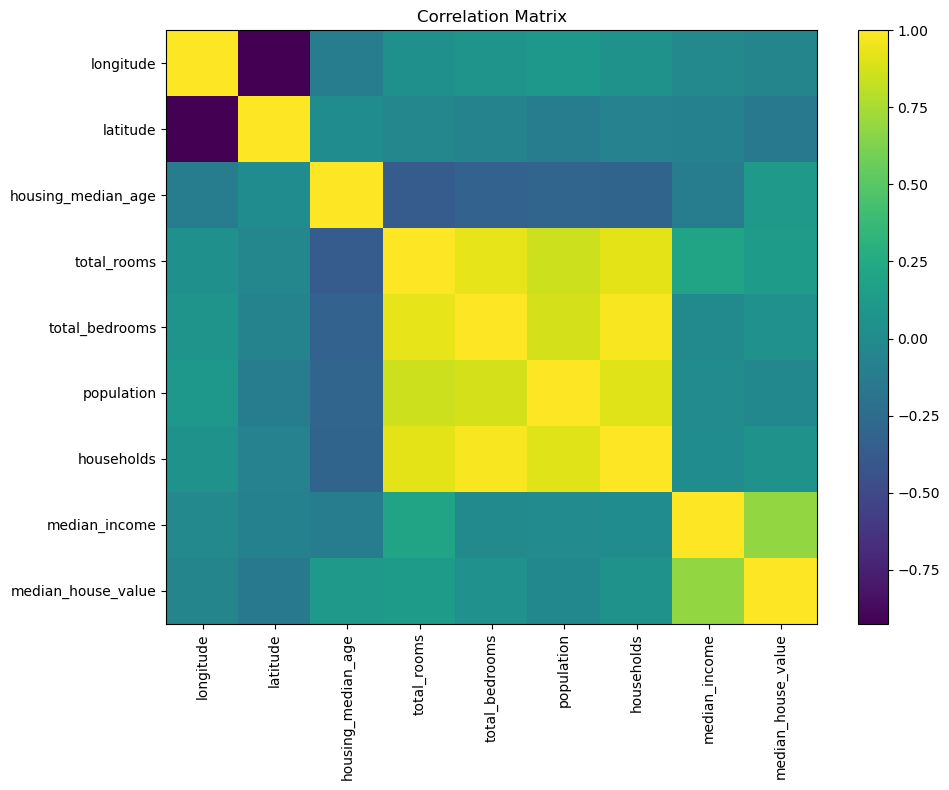

In [124]:
# Correlation matrix for numerical features
corr = df[num_cols].corr()
# Create a heatmap to visualize the correlation matrix
fig, ax = plt.subplots(figsize=(10,8))

im = ax.imshow(corr, aspect='auto')
# Set x and y ticks to the number of columns in the correlation matrix
ax.set_xticks(range(len(corr.columns)))
# Set x and y tick labels to column names
ax.set_xticklabels(corr.columns, rotation=90)
# Set y ticks and labels
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
# Add colorbar to show correlation values
# im means
plt.colorbar(im)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()




In [125]:
print(corr['median_house_value'].sort_values(ascending=False))

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


## Missing Values

In [126]:
missing = df.isnull().sum()
missing[missing > 0]


total_bedrooms    207
dtype: int64

## Categorical Analys

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


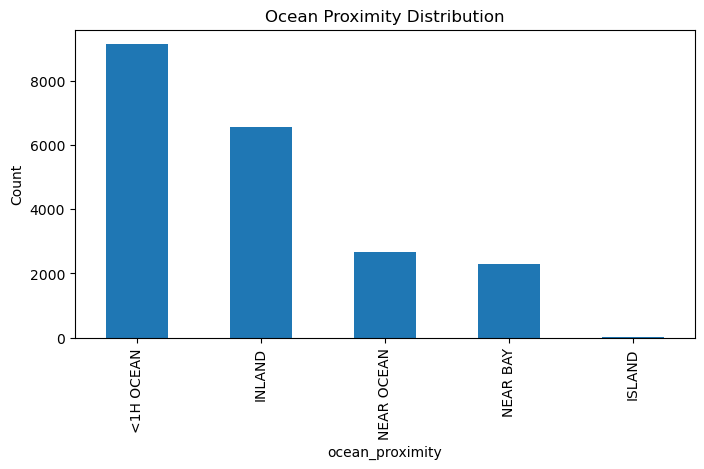

In [127]:
if 'ocean_proximity' in df.columns:
    print(df['ocean_proximity'].value_counts())

    df['ocean_proximity'].value_counts().plot(kind='bar', figsize=(8,4))
    plt.title('Ocean Proximity Distribution')
    plt.ylabel('Count')
    plt.show()


## kommentar
vi har inte  balanserad data, det finns färre observationer av vissa kategorier. Jag behöver ta ställning till ISLAND data med bara 5 observationer, kanske ignorera den kategorin?


In [128]:
# Display value counts for ocean_proximity so have an estimate of the amount of data collected per
if 'ocean_proximity' in df.columns:
    print(df['ocean_proximity'].value_counts())

  


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


## House Value by Ocean Proximity

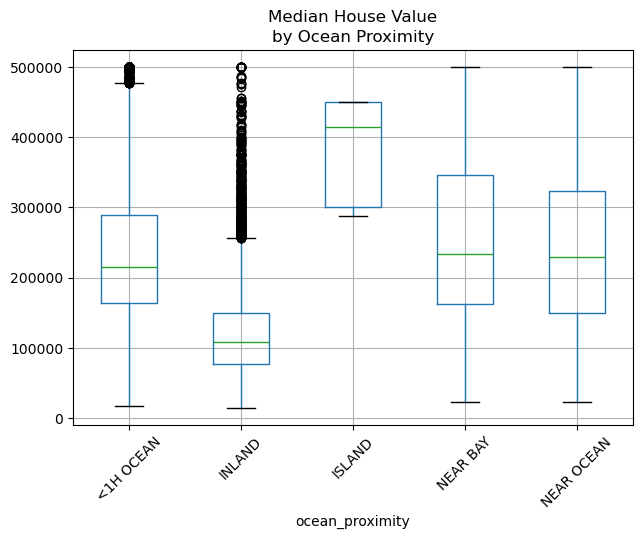

In [129]:
#
if 'ocean_proximity' in df.columns:
    df.boxplot(column='median_house_value', by='ocean_proximity', figsize=(7,5))
    plt.xticks(rotation=45)
    plt.suptitle('Median House Value')
    plt.title('by Ocean Proximity')
    plt.show()


# Kommentar
Det finns många outliers i INLAND kategorin med förmodligen lyxiga hem. Kanske behövs det en logarimisk skala. Åter igen, hem som ligger på en ö är mest eftertraktade efterssom de är relativ få hus men vi har för lite observations av ISLAND-kategorin

## House value per Location

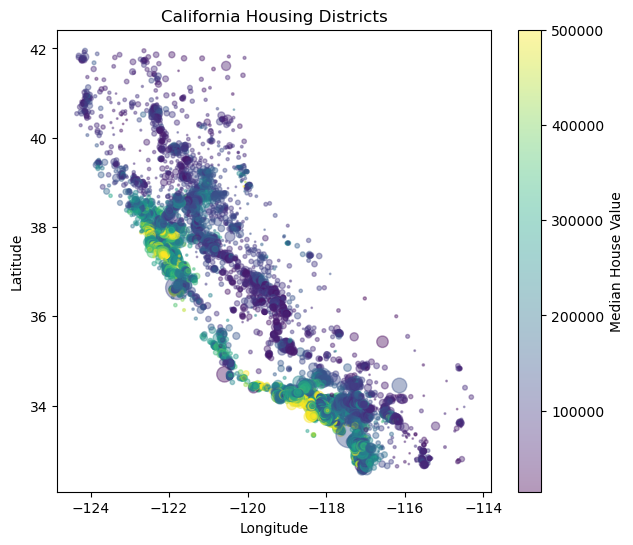

In [130]:
plt.figure(figsize=(7,6))
# Scatter plot of longitude vs latitude, colored by median house value and sized by population
plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['median_house_value'],
    s=np.maximum(df['population'] / 100, 1),
    alpha=0.4
)
# Add colorbar and labels
plt.colorbar(label='Median House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Districts')
plt.show()


## Lägg till en Karta för att öka diagram förståelse
>Notera prisändring runt San Francisco Bay Area och Los Angeles 
![California Map](california_map.png)

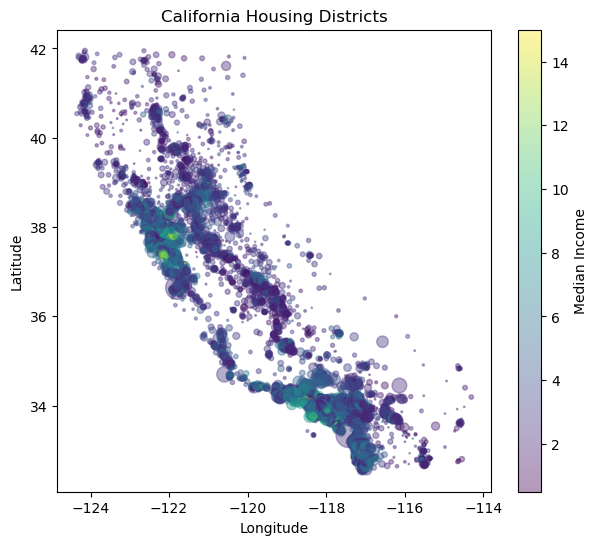

In [131]:
plt.figure(figsize=(7,6))
# Scatter plot of longitude vs latitude, colored by median income and sized by population
plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['median_income'],
    s=np.maximum(df['population'] / 100, 1),
    alpha=0.4
)
plt.colorbar(label='Median Income')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Districts')
plt.show()


## Feature Engineering, förslag på konstruerade variable som kan vara intressanta att utvärdera
>
- **Rooms per household**       = `total_rooms / households`
- **Bedrooms per room**         = `total_bedrooms / total_rooms`
- **Population per household**  = `population / households`

""

In [132]:
# Create new features based on existing ones
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

# Display the correlation of the new features and old features with median_house_value
print(df[['rooms_per_household',
    'bedrooms_per_room',
    'population_per_household',
    'total_rooms',
    'total_bedrooms',
    'total_rooms',
    'median_house_value']].corr()['median_house_value'].sort_values(ascending=False))


median_house_value          1.000000
rooms_per_household         0.151948
total_rooms                 0.134153
total_rooms                 0.134153
total_bedrooms              0.049686
population_per_household   -0.023737
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64


## Outliers

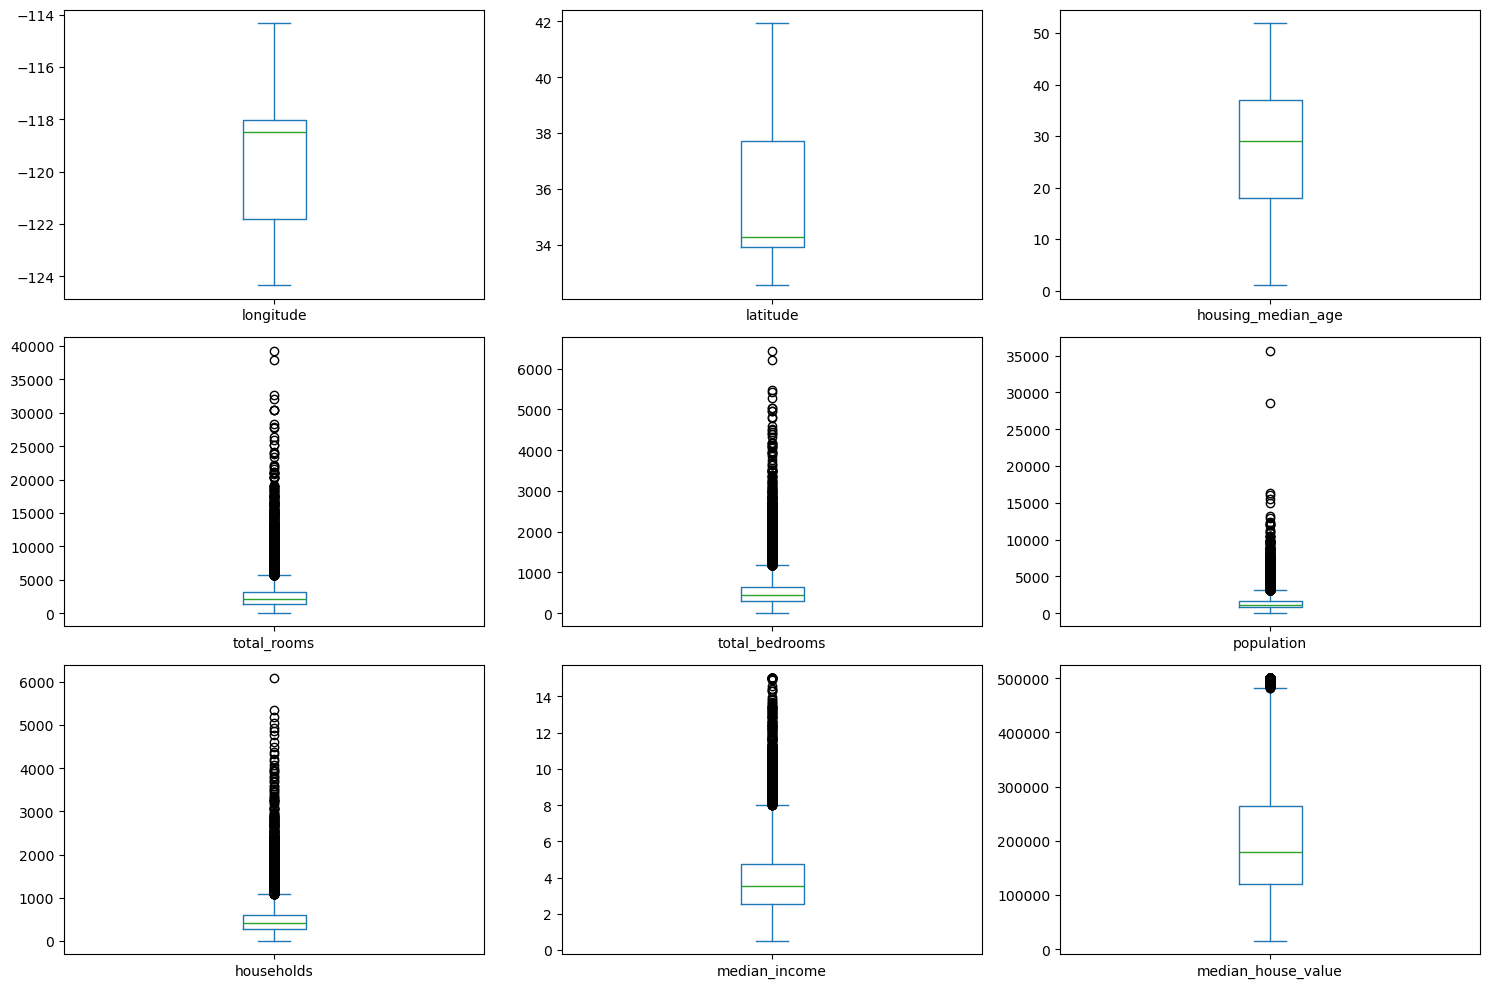

In [133]:
# Box plots for numerical features to check for outliers
df[num_cols].plot(kind='box', subplots=True, layout=(3,3),
                  figsize=(15,10), sharex=False)
plt.tight_layout()
plt.show()


## Några frågor och svar hittils (to be continued efter sommar)

I - Vilka variabler har starkast korrelation med median_house_value? 
>median_income  
förmodligen ocean_proximity men den måste göras till numerisk och jag vet inte vilken metod är lämpligast.
Island = 5, near_ocean = 4, near_bay = 3, <1htillocean = 2, inland=1 Problemet jag ser är att vi har för lite data av kategorin ISLAND

II - Är kustnära distrikt dyrare än distrikt som ligger längre inåt landet?
>Ja men det lär finnas en del förmodligen exklusiva hem eller område inåt landet 

III - Finns det tydliga geografiska kluster med höga bostadsvärden?
>Ja, kluster av distrikt med hög medelinkomst, finare kvarterer

IV - Finns det snedfördelade variabler eller extremvärden (outliers) som behöver transformeras?
>Ja, det verkar så men jag är f.n. osäker på det bästa sätet att göra de. Jag hoppas på att utveckla mig i ämnet efter sommaren.

V - Förbättrar konstruerade variabler (feature engineering) modellens förklaringsgrad?
>Jag hittade en, bedrooms_per_room som har högre negativ korrelation än komponentvariablerna var för sig

>median_house_value          1.000000

>total_rooms                 0.134153

>total_bedrooms              0.049686

>bedrooms_per_room          -0.255880


## Självutvärdering 
1. Har något varit utmanande i kursen/kunskapskontrollerna? Om ja, hur har du 
hanterat det? Vilka lärdomar tar du med dig till framtida kurser? 
>Ja, vissa delar var utmanande, framför allt konfiguration av GitHub och Python-miljön. Notebook markdown. Även AI-etik frågorna då det var ett omfattande område med många perspektiv och dilemman att sätta sig in i. Jag hanterade detta genom att läsa dokumentation, söka information och lägga extra tid på att förstå de olika frågorna. Till framtida kurser tar jag med mig vikten av att arbeta strukturerat, börja i god tid och vara uthållig när jag stöter på tekniska eller komplexa problem.

2. Vilket betyg anser du att du ska ha och varför? 

>Jag anser att jag kanske bör få VG, eftersom jag har lagt ner mycket tid och engagemang på kursen. EDA är ett brett ämne, och jag har arbetat noggrant med analysfrågorna samt visat förståelse för kursens innehåll genom mina resonemang och reflektioner. Samtidigt har det viktigaste för mig varit lärandet och att utveckla min förståelse för ämnet, snarare än själva betyget.

3. Något du vill lyfta fram till Terese? 
>Jag uppskattar ditt sätt att uppmuntra alla att bidra till lärandet och att du är öppen med att du inte alltid har alla svar. Det skapar en trygg och positiv lärandemiljö där det känns naturligt att ställa frågor och bidra med olika perspektiv.